# **Ford GoBike Exploratory Data Analysis (EDA) Using Python**

### **Problem Statement**

Ford GoBike generates large volumes of trip data every day, containing valuable information about customer behavior, ride patterns, station usage, and service demand. However, raw data alone cannot support effective business decisions. The challenge is to transform this data into meaningful insights by identifying trends, peak usage periods, popular stations, ride duration patterns, and customer characteristics. This project uses Exploratory Data Analysis (EDA) to clean, integrate, and analyze one year of trip data, helping Ford GoBike understand customer behavior, improve operational efficiency, optimize resource allocation, and enhance the overall bike-sharing experience through data-driven decision-making.


### **Business Objective**

The primary objective of this project is to analyze one year of Ford GoBike trip data using Exploratory Data Analysis (EDA) to understand customer behavior, operational performance, and usage patterns. The specific objectives are:

* To analyze the demographic profile of riders, including user type, age, and gender.
* To identify ride patterns across different months, weekdays, and hours of the day.
* To examine ride duration and understand how it varies among different customer groups.
* To identify the most frequently used start and end stations for efficient resource planning.
* To explore relationships between different variables and uncover meaningful trends.
* To generate actionable business insights that improve operational efficiency and customer experience.
* To provide data-driven recommendations that support better decision-making and optimize the Ford GoBike bike-sharing service.


## **Data Collection & Integration**

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# File Handling
import glob
import os

In [2]:
# Folder containing all monthly CSV files
data_path = "Data/*.csv"

In [3]:
# Find all CSV files
csv_files = glob.glob(data_path)

# Display total files found
print("Total CSV Files:", len(csv_files))

Total CSV Files: 12


In [4]:
# Read each CSV file
dataframes = []

for file in csv_files:
    df = pd.read_csv(file)
    dataframes.append(df)

In [5]:
# Merge all DataFrames
bike_data = pd.concat(dataframes, ignore_index=True)

In [6]:
# Check dataset dimensions
print("Rows and Columns:", bike_data.shape)

Rows and Columns: (1863721, 16)


## **Initial Dataset Exploration**

In [7]:
# Display first five rows
bike_data.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,75284,2018-01-31 22:52:35.2390,2018-02-01 19:47:19.8240,120.0,Mission Dolores Park,37.761420,-122.426435,285.0,Webster St at O'Farrell St,37.783521,-122.431158,2765,Subscriber,1986.0,Male,No
1,85422,2018-01-31 16:13:34.3510,2018-02-01 15:57:17.3100,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,2815,Customer,NaN,NaN,No
2,71576,2018-01-31 14:23:55.8890,2018-02-01 10:16:52.1160,304.0,Jackson St at 5th St,37.348759,-121.894798,296.0,5th St at Virginia St,37.325998,-121.877120,3039,Customer,1996.0,Male,No
3,61076,2018-01-31 14:53:23.5620,2018-02-01 07:51:20.5000,75.0,Market St at Franklin St,37.773793,-122.421239,47.0,4th St at Harrison St,37.780955,-122.399749,321,Customer,NaN,NaN,No
4,39966,2018-01-31 19:52:24.6670,2018-02-01 06:58:31.0530,74.0,Laguna St at Hayes St,37.776435,-122.426244,19.0,Post St at Kearny St,37.788975,-122.403452,617,Subscriber,1991.0,Male,No


In [8]:
# Display last five rows
bike_data.tail()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
1863716,473,2018-12-01 00:11:54.8110,2018-12-01 00:19:48.5470,345.0,Hubbell St at 16th St,37.766474,-122.398295,81.0,Berry St at 4th St,37.775880,-122.393170,3035,Subscriber,1982.0,Female,No
1863717,841,2018-12-01 00:02:48.7260,2018-12-01 00:16:49.7660,10.0,Washington St at Kearny St,37.795393,-122.404770,58.0,Market St at 10th St,37.776619,-122.417385,2034,Subscriber,1999.0,Female,No
1863718,260,2018-12-01 00:05:27.6150,2018-12-01 00:09:47.9560,245.0,Downtown Berkeley BART,37.870139,-122.268422,255.0,Virginia St at Shattuck Ave,37.876573,-122.269528,2243,Subscriber,1991.0,Male,No
1863719,292,2018-12-01 00:03:06.5490,2018-12-01 00:07:59.0800,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,126.0,Esprit Park,37.761634,-122.390648,545,Subscriber,1963.0,Male,No
1863720,150,2018-12-01 00:03:05.7420,2018-12-01 00:05:36.0260,107.0,17th St at Dolores St,37.763015,-122.426497,119.0,18th St at Noe St,37.761047,-122.432642,4319,Subscriber,NaN,NaN,No


In [9]:
# Display column names
bike_data.columns

Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip'],
      dtype='object')

In [10]:
# Dataset information
bike_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1863721 entries, 0 to 1863720
Data columns (total 16 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   duration_sec             int64  
 1   start_time               object 
 2   end_time                 object 
 3   start_station_id         float64
 4   start_station_name       object 
 5   start_station_latitude   float64
 6   start_station_longitude  float64
 7   end_station_id           float64
 8   end_station_name         object 
 9   end_station_latitude     float64
 10  end_station_longitude    float64
 11  bike_id                  int64  
 12  user_type                object 
 13  member_birth_year        float64
 14  member_gender            object 
 15  bike_share_for_all_trip  object 
dtypes: float64(7), int64(2), object(7)
memory usage: 227.5+ MB


In [11]:
# Summary statistics
bike_data.describe().round(2)

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,1863721.00,1851950.00,1863721.00,1863721.00,1851950.00,1863721.00,1863721.00,1863721.00,1753003.00
mean,857.30,119.67,37.77,-122.35,118.17,37.77,-122.35,2296.85,1983.09
std,2370.38,100.40,0.11,0.17,100.44,0.11,0.17,1287.73,10.44
min,61.00,3.00,37.26,-122.47,3.00,37.26,-122.47,11.00,1881.00
25%,350.00,33.00,37.77,-122.41,30.00,37.77,-122.41,1225.00,1978.00
50%,556.00,89.00,37.78,-122.40,88.00,37.78,-122.40,2338.00,1985.00
75%,872.00,186.00,37.80,-122.29,183.00,37.80,-122.29,3333.00,1991.00
max,86366.00,381.00,45.51,-73.57,381.00,45.51,-73.57,6234.00,2000.00


In [12]:
# Unique values in each column
for column in bike_data.columns:
    print(f"\n{column}")
    print(bike_data[column].nunique())


duration_sec
16709

start_time
1863584

end_time
1863610

start_station_id
331

start_station_name
348

start_station_latitude
369

start_station_longitude
370

end_station_id
331

end_station_name
348

end_station_latitude
370

end_station_longitude
371

bike_id
5054

user_type
2

member_birth_year
86

member_gender
3

bike_share_for_all_trip
2


In [13]:
# Check category frequencies
bike_data['user_type'].value_counts()

user_type
Subscriber    1583554
Customer       280167
Name: count, dtype: int64

In [14]:
# Identify missing values
bike_data.isnull().sum()

duration_sec                    0
start_time                      0
end_time                        0
start_station_id            11771
start_station_name          11771
start_station_latitude          0
start_station_longitude         0
end_station_id              11771
end_station_name            11771
end_station_latitude            0
end_station_longitude           0
bike_id                         0
user_type                       0
member_birth_year          110718
member_gender              110367
bike_share_for_all_trip         0
dtype: int64

In [15]:
# Identify missing values
bike_data.duplicated().sum()

np.int64(0)

## **Data Cleaning**

In [16]:
# Create a copy of the merged dataset
df = bike_data.copy()

In [17]:
# Count missing values
df.isnull().sum()

duration_sec                    0
start_time                      0
end_time                        0
start_station_id            11771
start_station_name          11771
start_station_latitude          0
start_station_longitude         0
end_station_id              11771
end_station_name            11771
end_station_latitude            0
end_station_longitude           0
bike_id                         0
user_type                       0
member_birth_year          110718
member_gender              110367
bike_share_for_all_trip         0
dtype: int64

In [18]:
# Percentage of missing values
(df.isnull().sum()/len(df))*100

duration_sec               0.000000
start_time                 0.000000
end_time                   0.000000
start_station_id           0.631586
start_station_name         0.631586
start_station_latitude     0.000000
start_station_longitude    0.000000
end_station_id             0.631586
end_station_name           0.631586
end_station_latitude       0.000000
end_station_longitude      0.000000
bike_id                    0.000000
user_type                  0.000000
member_birth_year          5.940696
member_gender              5.921863
bike_share_for_all_trip    0.000000
dtype: float64

In [19]:
# Remove rows with missing Gender or Birth Year
df = df.dropna(subset=['member_gender', 'member_birth_year'])

In [20]:
# Count duplicate rows
df.duplicated().sum()

np.int64(0)

In [21]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [22]:
df.dtypes

duration_sec                 int64
start_time                  object
end_time                    object
start_station_id           float64
start_station_name          object
start_station_latitude     float64
start_station_longitude    float64
end_station_id             float64
end_station_name            object
end_station_latitude       float64
end_station_longitude      float64
bike_id                      int64
user_type                   object
member_birth_year          float64
member_gender               object
bike_share_for_all_trip     object
dtype: object

In [23]:
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1753003 entries, 0 to 1863719
Data columns (total 16 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   duration_sec             int64         
 1   start_time               datetime64[ns]
 2   end_time                 datetime64[ns]
 3   start_station_id         float64       
 4   start_station_name       object        
 5   start_station_latitude   float64       
 6   start_station_longitude  float64       
 7   end_station_id           float64       
 8   end_station_name         object        
 9   end_station_latitude     float64       
 10  end_station_longitude    float64       
 11  bike_id                  int64         
 12  user_type                object        
 13  member_birth_year        float64       
 14  member_gender            object        
 15  bike_share_for_all_trip  object        
dtypes: datetime64[ns](2), float64(7), int64(2), object(5)
memory usage: 227.4+ MB

In [25]:
df['age'] = 2018 - df['member_birth_year']

In [26]:
df = df[(df['age'] >= 10) & (df['age'] <= 100)]

In [27]:
df = df[df['duration_sec'] > 0]

## **Feature Engineering**

In [28]:
df['ride_duration_min'] = df['duration_sec'] / 60

In [29]:
df['ride_hour'] = df['start_time'].dt.hour

In [30]:
df['ride_day'] = df['start_time'].dt.day_name()

In [31]:
df['ride_month'] = df['start_time'].dt.month_name()

In [32]:
df['age'] = 2018 - df['member_birth_year']

In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.isnull().sum()

duration_sec                   0
start_time                     0
end_time                       0
start_station_id           11447
start_station_name         11447
start_station_latitude         0
start_station_longitude        0
end_station_id             11447
end_station_name           11447
end_station_latitude           0
end_station_longitude          0
bike_id                        0
user_type                      0
member_birth_year              0
member_gender                  0
bike_share_for_all_trip        0
age                            0
ride_duration_min              0
ride_hour                      0
ride_day                       0
ride_month                     0
dtype: int64

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1751843 entries, 0 to 1863719
Data columns (total 21 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   duration_sec             int64         
 1   start_time               datetime64[ns]
 2   end_time                 datetime64[ns]
 3   start_station_id         float64       
 4   start_station_name       object        
 5   start_station_latitude   float64       
 6   start_station_longitude  float64       
 7   end_station_id           float64       
 8   end_station_name         object        
 9   end_station_latitude     float64       
 10  end_station_longitude    float64       
 11  bike_id                  int64         
 12  user_type                object        
 13  member_birth_year        float64       
 14  member_gender            object        
 15  bike_share_for_all_trip  object        
 16  age                      float64       
 17  ride_duration_min        float64

In [36]:
df.shape

(1751843, 21)

## **Exploratory Data Analysis (EDA)**

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font_scale=1.1)

FORD_BLUE = "#0077B6"
LIGHT_BLUE = "#48CAE4"
CYAN = "#90E0EF"
NAVY = "#023E8A"
ORANGE = "#F77F00"

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

### **Univariate Analysis**

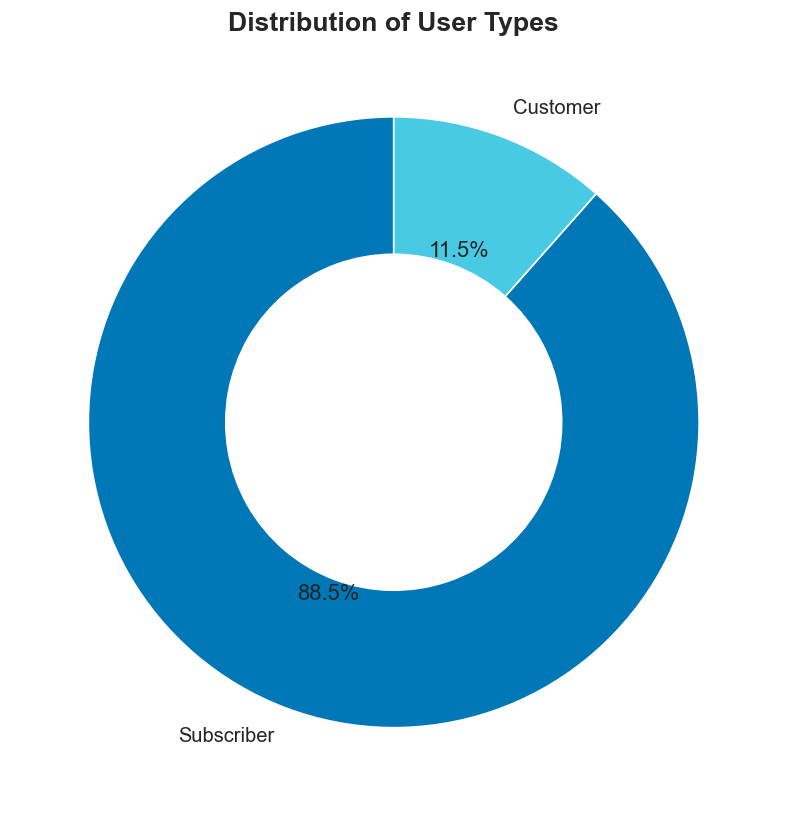

In [38]:
user_counts = df['user_type'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    user_counts,
    labels=user_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=[FORD_BLUE, LIGHT_BLUE],
    wedgeprops=dict(width=0.45, edgecolor='white')
)

plt.title("Distribution of User Types")
plt.tight_layout()
plt.show()

**Purpose:** This chart compares the distribution of rides between Subscribers and Customers.

**Insight:** Subscribers contribute the majority of total rides, indicating a strong membership base.

**Business Impact:** Encourages strategies to increase memberships and improve customer retention.


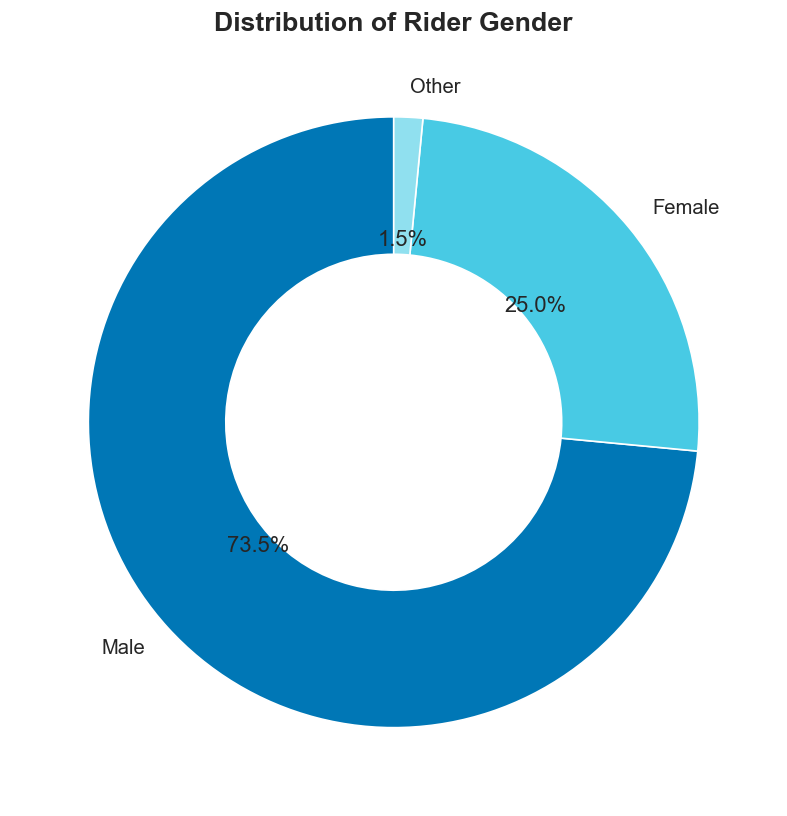

In [39]:
gender_counts = df['member_gender'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=[FORD_BLUE, LIGHT_BLUE, CYAN],
    wedgeprops=dict(width=0.45, edgecolor='white')
)

plt.title("Distribution of Rider Gender")
plt.tight_layout()
plt.show()

**Purpose:** This chart shows the distribution of riders across different gender categories.

**Insight:** The dataset reveals the gender composition of Ford GoBike users.

**Business Impact:** Supports targeted marketing campaigns and inclusive service planning.


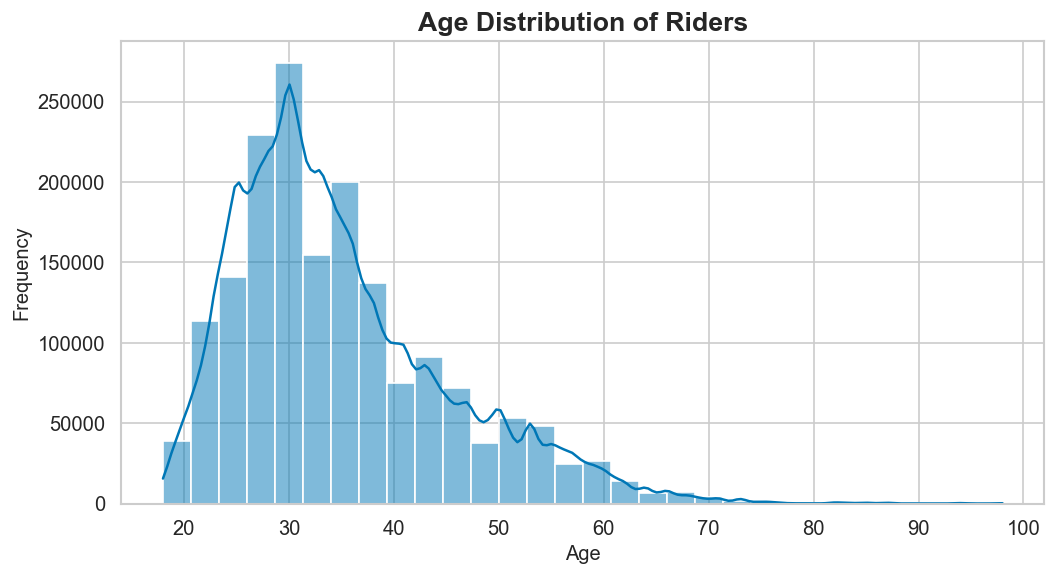

In [40]:
plt.figure(figsize=(9,5))

sns.histplot(
    df['age'],
    bins=30,
    color=FORD_BLUE,
    kde=True
)

plt.title("Age Distribution of Riders")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Purpose:** This chart illustrates the age distribution of riders.

**Insight:** Most riders belong to the young and middle-aged population.

**Business Impact:** Helps identify the primary customer segment for marketing and service improvements.


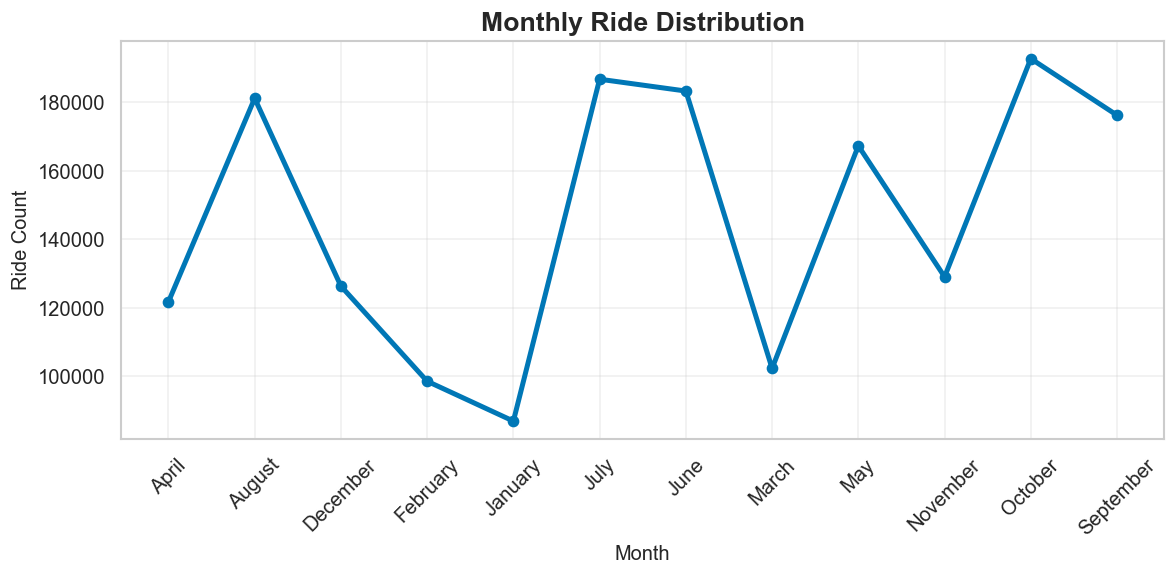

In [41]:
monthly = df['ride_month'].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(
    monthly.index,
    monthly.values,
    marker='o',
    linewidth=3,
    color=FORD_BLUE
)

plt.xticks(rotation=45)

plt.title("Monthly Ride Distribution")
plt.xlabel("Month")
plt.ylabel("Ride Count")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Purpose:** This chart compares ride frequency across different months.

**Insight:** Ride demand varies throughout the year, indicating seasonal usage patterns.

**Business Impact:** Supports demand forecasting and efficient resource planning.


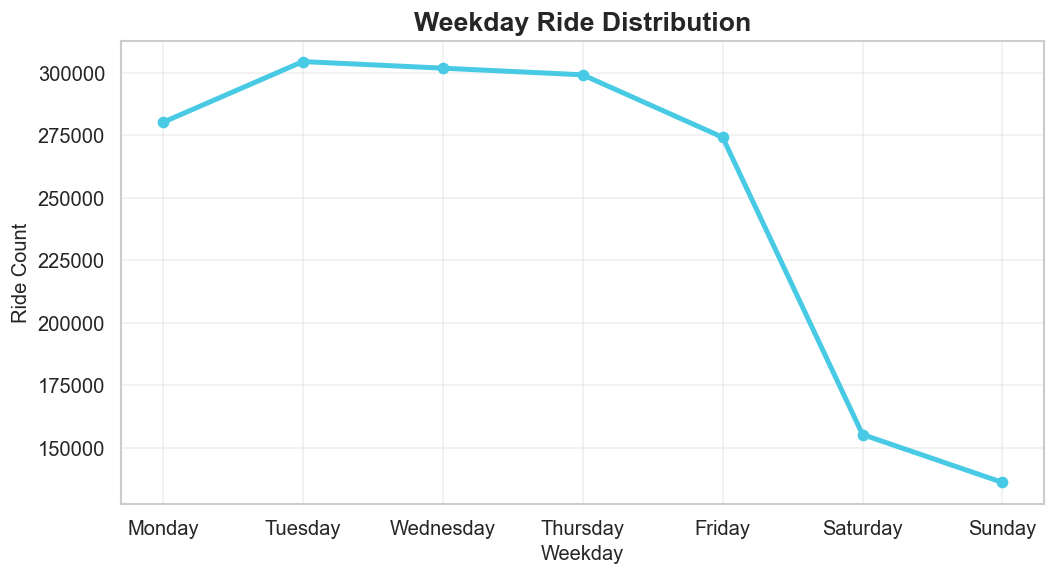

In [42]:
weekday_order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
]

weekday = df['ride_day'].value_counts().reindex(weekday_order)

plt.figure(figsize=(9,5))

plt.plot(
    weekday.index,
    weekday.values,
    marker='o',
    linewidth=3,
    color=LIGHT_BLUE
)

plt.title("Weekday Ride Distribution")
plt.xlabel("Weekday")
plt.ylabel("Ride Count")

plt.grid(alpha=.3)

plt.tight_layout()
plt.show()

**Purpose:** This chart compares ride activity across the days of the week.

**Insight:** Ride demand differs between weekdays and weekends.

**Business Impact:** Helps optimize staffing and operational planning.

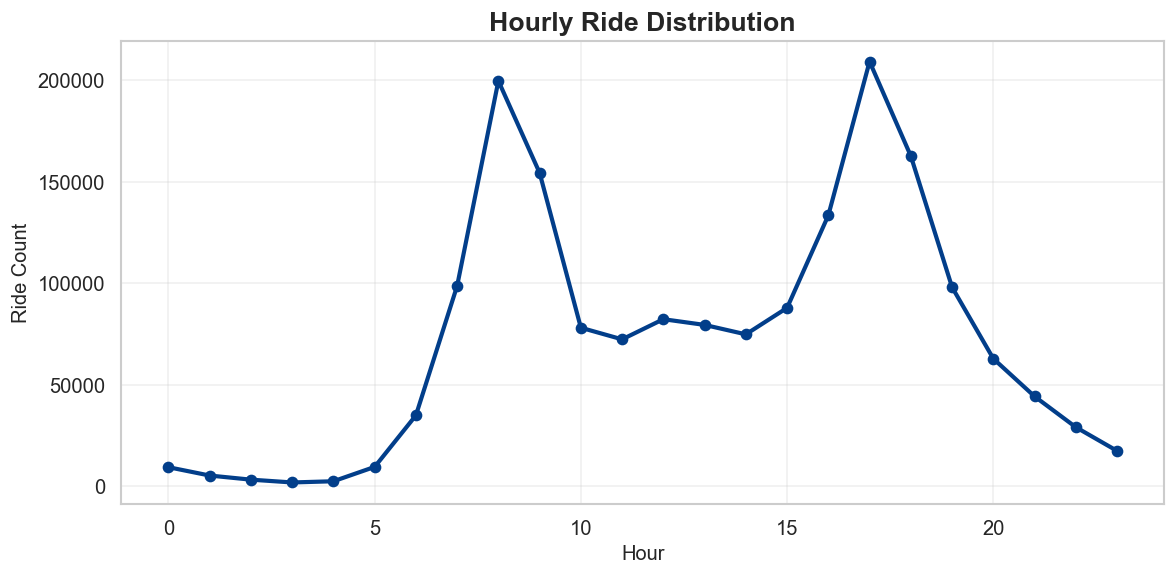

In [43]:
hourly = df['ride_hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(
    hourly.index,
    hourly.values,
    marker='o',
    linewidth=2.5,
    color=NAVY
)

plt.title("Hourly Ride Distribution")
plt.xlabel("Hour")
plt.ylabel("Ride Count")

plt.grid(alpha=.3)

plt.tight_layout()
plt.show()

**Purpose:** This chart identifies ride activity during different hours of the day.

**Insight:** Ride demand peaks during specific commuting hours.

**Business Impact:** Helps improve bike availability during peak demand periods.


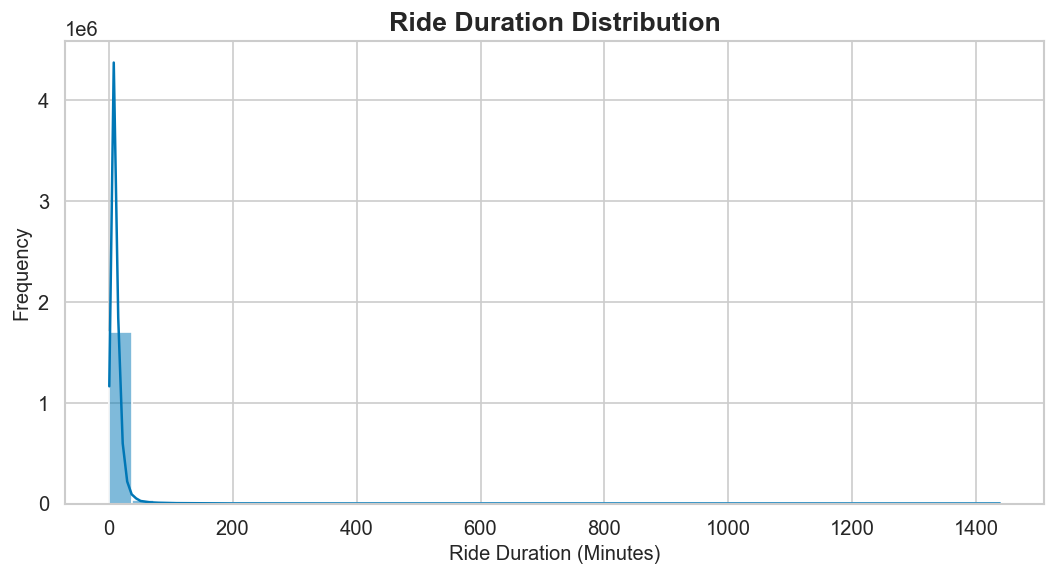

In [44]:
plt.figure(figsize=(9,5))

sns.histplot(
    df['ride_duration_min'],
    bins=40,
    color=FORD_BLUE,
    kde=True
)

plt.title("Ride Duration Distribution")
plt.xlabel("Ride Duration (Minutes)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Purpose:** This chart shows the distribution of ride durations.

**Insight:** Most trips are short, while only a few have long ride durations.

**Business Impact:** Provides insights into customer travel behavior and service usage.


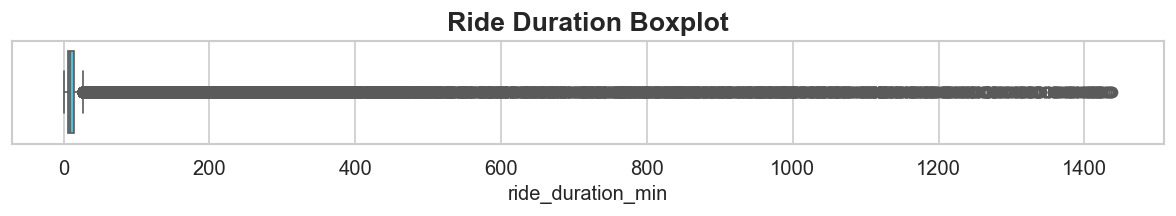

In [45]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df['ride_duration_min'],
    color=LIGHT_BLUE
)

plt.title("Ride Duration Boxplot")

plt.tight_layout()
plt.show()

**Purpose:** This chart identifies the spread and outliers in ride duration.

**Insight:** A small number of unusually long rides are present in the dataset.

**Business Impact:** Helps identify abnormal ride patterns for further investigation.


### **Bivariate Analysis**

C:\Users\anshs\AppData\Local\Temp\ipykernel_7024\2576863226.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


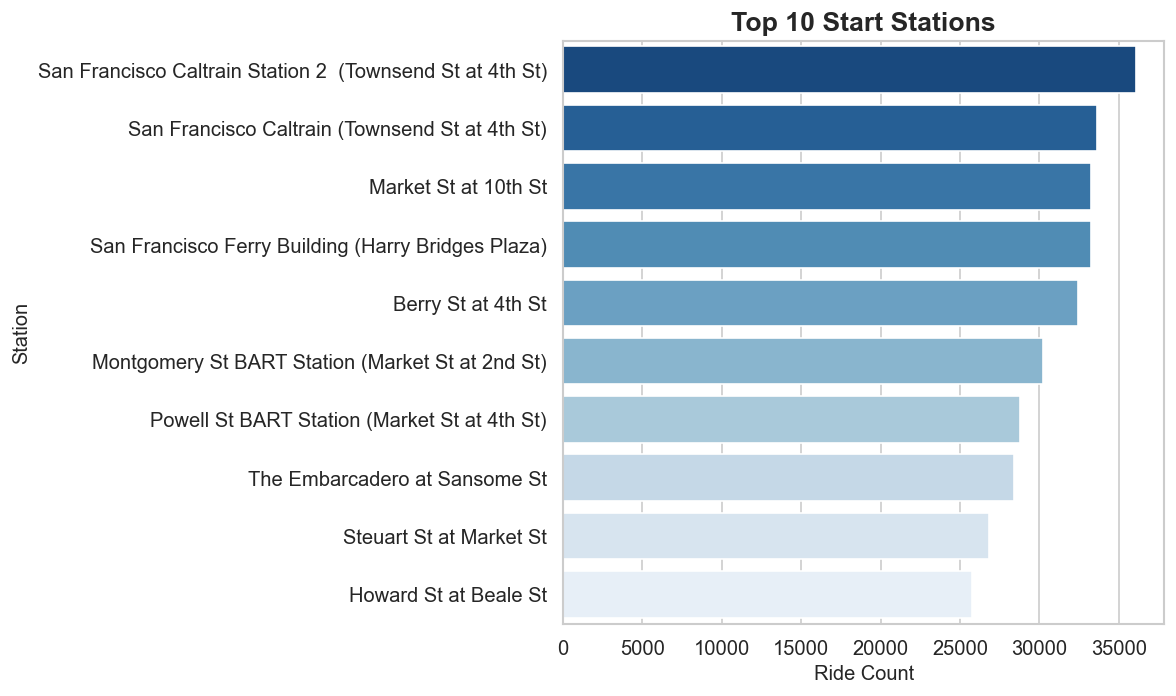

In [46]:
station_df = df.dropna(subset=['start_station_name'])

top_start = station_df['start_station_name'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_start.values,
    y=top_start.index,
    palette="Blues_r"
)

plt.title("Top 10 Start Stations")
plt.xlabel("Ride Count")
plt.ylabel("Station")

plt.tight_layout()
plt.show()

**Purpose:** This chart highlights the most frequently used start stations.

**Insight:** A few stations generate significantly higher ride volumes than others.

**Business Impact:** Supports better bike allocation and station management.


C:\Users\anshs\AppData\Local\Temp\ipykernel_7024\4167618425.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


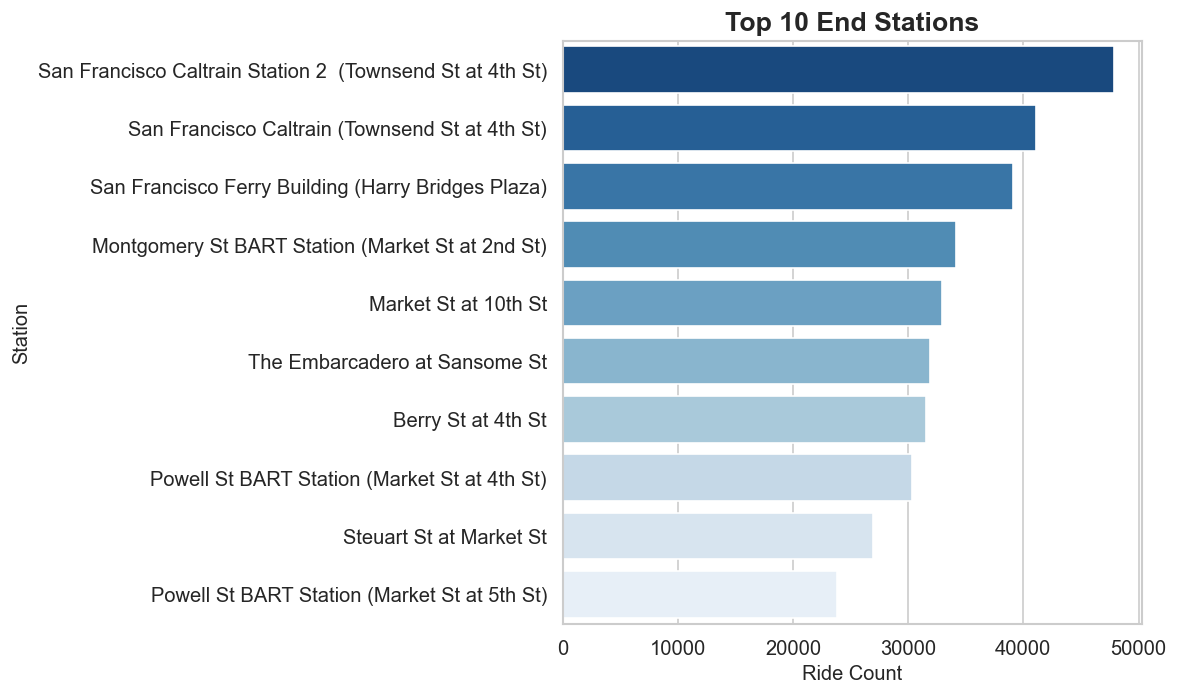

In [47]:
station_df = df.dropna(subset=['end_station_name'])

top_end = station_df['end_station_name'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_end.values,
    y=top_end.index,
    palette="Blues_r"
)

plt.title("Top 10 End Stations")
plt.xlabel("Ride Count")
plt.ylabel("Station")

plt.tight_layout()
plt.show()

**Purpose:** This chart identifies the busiest destination stations.

**Insight:** Certain stations consistently receive the highest number of ride endings.

**Business Impact:** Helps improve bike redistribution and docking availability.


C:\Users\anshs\AppData\Local\Temp\ipykernel_7024\2861507488.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


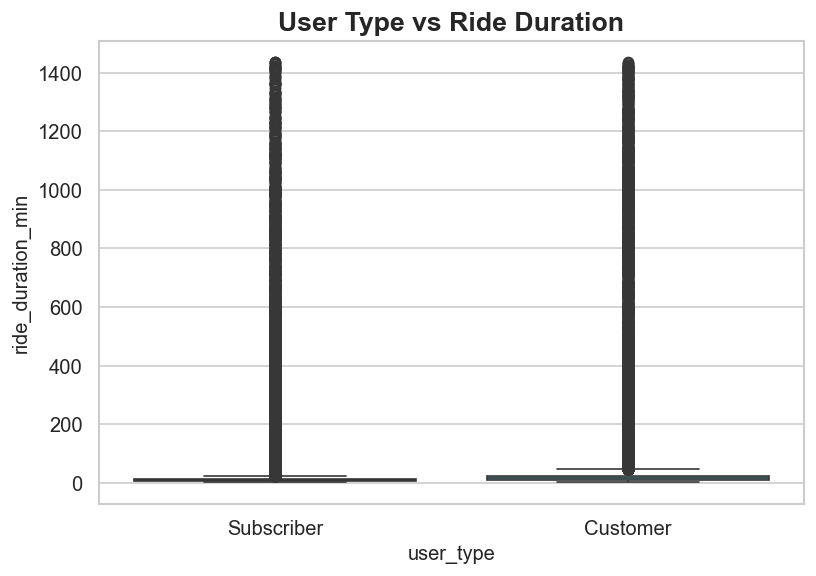

In [48]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='user_type',
    y='ride_duration_min',
    palette=[FORD_BLUE, LIGHT_BLUE]
)

plt.title("User Type vs Ride Duration")

plt.tight_layout()
plt.show()

**Purpose:** This chart compares ride duration across different user types.

**Insight:** Ride duration varies between Subscribers and Customers.

**Business Impact:** Supports customer-specific pricing and membership strategies.


C:\Users\anshs\AppData\Local\Temp\ipykernel_7024\85771978.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


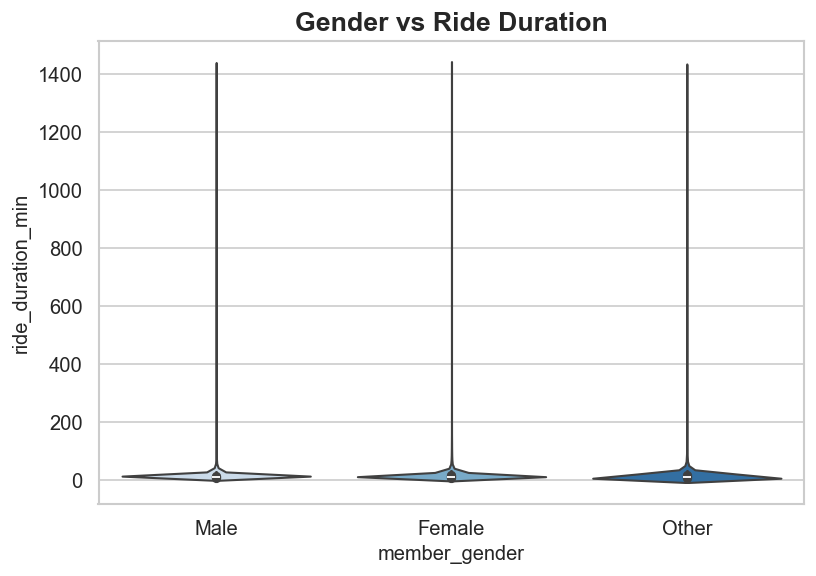

In [49]:
plt.figure(figsize=(7,5))

sns.violinplot(
    data=df,
    x='member_gender',
    y='ride_duration_min',
    palette="Blues"
)

plt.title("Gender vs Ride Duration")

plt.tight_layout()
plt.show()

**Purpose:** This chart compares ride duration across different gender groups.

**Insight:** Ride duration shows slight variation among gender categories.

**Business Impact:** Helps understand customer behavior for service planning.


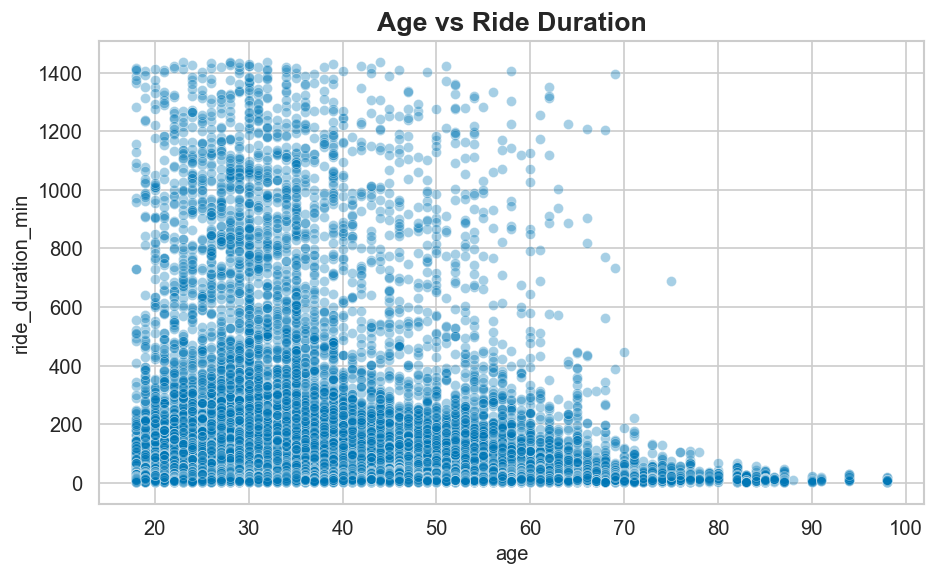

In [50]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='age',
    y='ride_duration_min',
    color=FORD_BLUE,
    alpha=0.35
)

plt.title("Age vs Ride Duration")

plt.tight_layout()
plt.show()

**Purpose:** This chart examines the relationship between rider age and ride duration.

**Insight:** No strong relationship is observed between age and ride duration.

**Business Impact:** Helps determine whether age significantly influences riding behavior.


### **Multivariate Analysis**

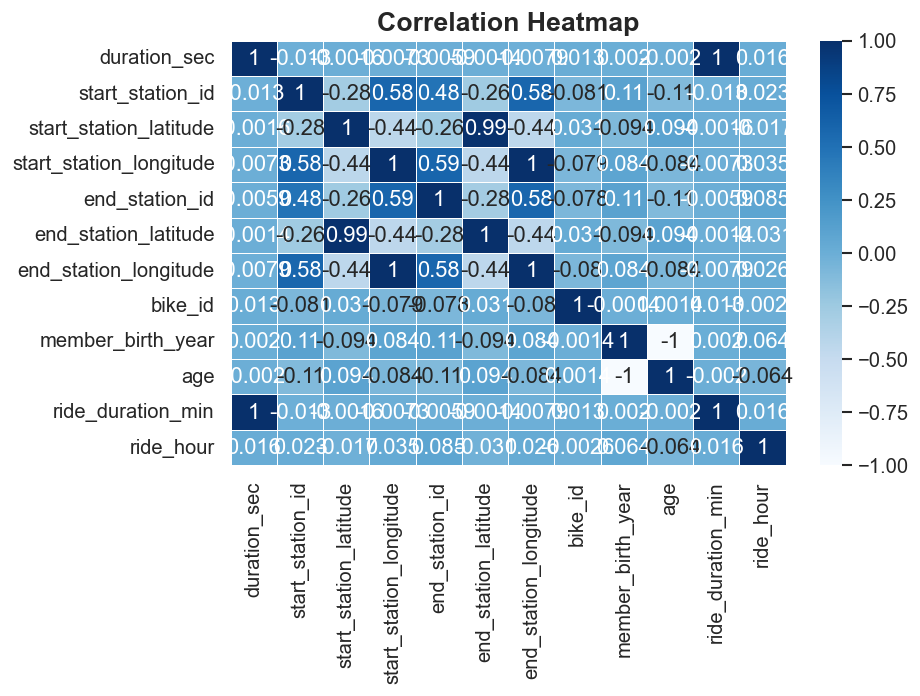

In [51]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include='number')

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Blues",
    linewidths=.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

**Purpose:** This chart displays the correlation between numerical variables.

**Insight:** Most variables exhibit weak to moderate correlations.

**Business Impact:** Helps identify important variables for future analysis and predictive modeling.


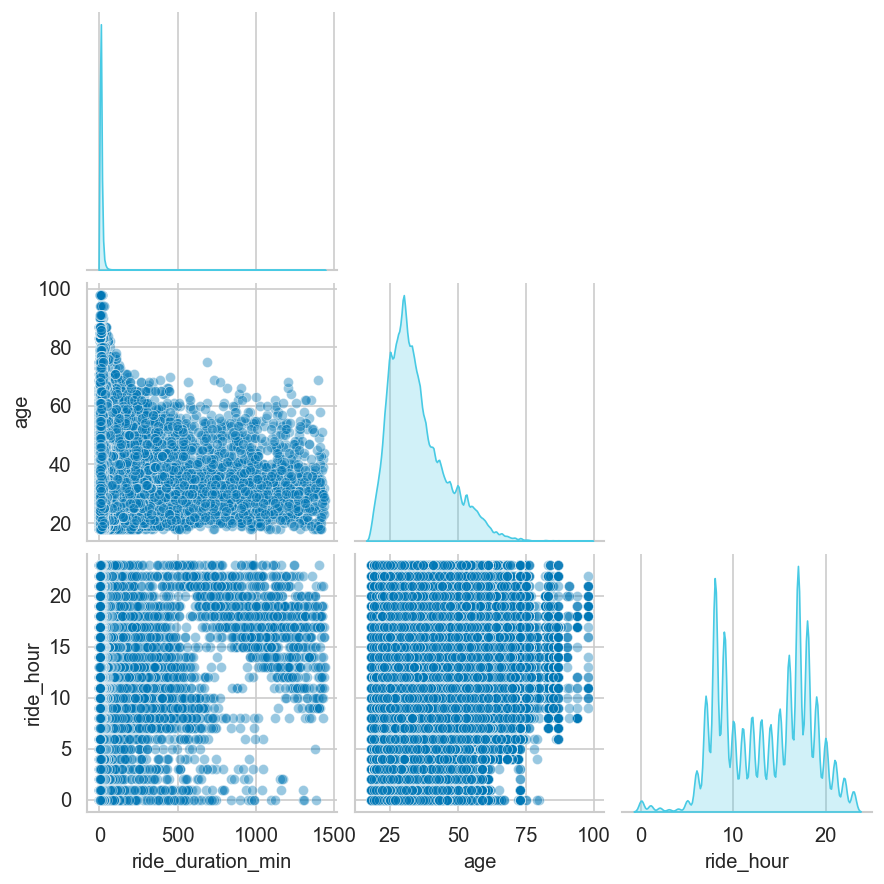

In [52]:
sns.pairplot(
    df[
        [
            'ride_duration_min',
            'age',
            'ride_hour'
        ]
    ],
    corner=True,
    diag_kind='kde',
    plot_kws={'color': FORD_BLUE, 'alpha':0.4},
    diag_kws={'color': LIGHT_BLUE}
)

plt.show()

**Purpose:** This chart visualizes relationships among multiple numerical variables.

**Insight:** It reveals overall variable distributions and potential relationships.

**Business Impact:** Provides a comprehensive understanding of the dataset to support data-driven decision-making.


### **Business Insights**

Based on the Exploratory Data Analysis (EDA), the following key business insights were identified:

* Subscribers contribute the majority of total rides, indicating that membership-based users form the primary customer base of the bike-sharing system.

* Ride demand is highest during weekday commuting hours, suggesting that the service is primarily used for daily travel and work-related commuting.

* Most trips are short in duration, indicating that customers mainly use the bikes for short-distance transportation.

* A few stations consistently experience significantly higher ride activity than others, making them critical locations for bike availability and redistribution.

* Customer riding behavior varies across different user types and age groups, providing valuable information for targeted operational and marketing strategies.

* The analysis revealed clear temporal and spatial riding patterns that can support better resource allocation, operational planning, and overall customer satisfaction.


### **Business Recommendations**

Based on the findings obtained from the Exploratory Data Analysis (EDA), the following business recommendations are proposed to improve the operational efficiency and customer experience of the Ford GoBike bike-sharing system:

1. **Optimize Bike Availability During Peak Hours:** Since ride demand is highest during peak commuting hours, additional bikes should be deployed to high-demand stations before these periods to ensure better availability and reduce customer wait times.

2. **Implement an Efficient Bike Redistribution Strategy:** Frequently used stations should be monitored regularly, and bikes should be redistributed from low-demand stations to high-demand stations to maintain a balanced supply across the network.

3. **Promote Subscription Memberships:** As subscribers account for the majority of rides, promotional campaigns, referral programs, and membership discounts can encourage occasional customers to become long-term subscribers, improving customer retention and revenue.

4. **Enhance Maintenance Planning:** Bikes operating at high-traffic stations should be inspected and maintained more frequently to minimize equipment failures, improve rider safety, and ensure reliable service.

5. **Improve Operational Planning Using Demand Patterns:** Historical ride patterns should be used to optimize staffing, maintenance schedules, and bike allocation during periods of high demand, resulting in more efficient operations.

6. **Adopt Continuous Performance Monitoring:** Interactive dashboards should be developed to monitor key performance indicators such as ride volume, station utilization, ride duration, and customer demographics. Continuous monitoring will support data-driven decision-making and enable timely operational improvements.

**Overall Recommendation:** Implementing these data-driven recommendations can help Ford GoBike improve bike availability, optimize station operations, enhance customer satisfaction, increase membership retention, and support long-term operational efficiency and sustainable business growth.


### **Conclusion**

This project successfully analyzed one year of Ford GoBike trip data using Exploratory Data Analysis (EDA) techniques. The datasets were integrated, cleaned, and transformed to ensure high data quality before performing statistical analysis and visualization. The analysis provided valuable insights into customer demographics, ride duration, riding patterns, station utilization, and peak demand periods.

The findings revealed that subscribers account for the majority of rides, ride demand is highest during weekday commuting hours, and most trips are relatively short in duration. The analysis also identified high-traffic stations and meaningful relationships between rider characteristics and trip behavior. Based on these findings, several data-driven recommendations were proposed to improve bike availability, optimize station operations, enhance customer satisfaction, and support efficient resource allocation.

Overall, this project demonstrates how Exploratory Data Analysis can transform raw transportation data into meaningful business insights that support informed decision-making and contribute to the continuous improvement of a bike-sharing service.
